1：Load the data and clean process

In [1]:
#Set the emviromment
#install.packages("BiocManager")
#BiocManager::install("DESeq2")
#install.packages("ggsignif") 
#BiocManager::install("org.Mm.eg.db")
#BiocManager::install("clusterProfiler")
library(dplyr)
library(DESeq2)
library(clusterProfiler)
library(ggplot2)
library(pheatmap)
library(tidyverse)
library(ggsignif)
library(org.Hs.eg.db) 
library(org.Mm.eg.db) 
library(AnnotationDbi)
library(enrichplot)
library(ggrepel)

Warning message:
"package 'dplyr' was built under R version 4.5.3"



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: S4Vectors



...


Attaching package: 'AnnotationDbi'




The following object is masked from 'package:clusterProfiler':

    select




The following object is masked from 'package:dplyr':

    select




enrichplot v1.30.5 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

G Yu. Thirteen years of clusterProfiler. The Innovation. 2024,
5(6):100722



Warning message:
"package 'ggrepel' was built under R version 4.5.3"


In [2]:
#import and mouse data
df_ms <- read.csv("coldata_ms.csv", header = TRUE, row.names = NULL)

In [3]:
#Check the data
#head(df_ms)

In [4]:
#get the analysed in mouse
countData_matrix_ms <- df_ms %>% 
  tibble::column_to_rownames(var = "gene_id") %>%
  as.matrix()

In [5]:
#check the data
#head(countData_matrix_hsa)
#head(countData_matrix_ms)

In [6]:
#in the mouse dataset
samples_ms <- colnames(countData_matrix_ms) 
condition_ms <- c(rep("NT",3), rep("MBCD",3), rep("STm",3), rep("STm_MBCD",3))
coldata_ms <- data.frame(row.names = samples_ms,
                      condition_ms = factor(condition_ms, levels=c("NT","MBCD","STm","STm_MBCD")))

In [7]:
#check
coldata_ms

,condition_ms
,<fct>
m411_NT1,NT
m411_NT2,NT
m411_NT3,NT
m411_MBCD1,MBCD
m411_MBCD2,MBCD
m411_MBCD3,MBCD
m411_STm1,STm
m411_STm2,STm
m411_STm3,STm


In [8]:
#building the DES object
#mouse data set
dds_ms <- DESeqDataSetFromMatrix(
  countData = round(countData_matrix_ms),
  colData = coldata_ms,
  design = ~ condition_ms
)

converting counts to integer mode



In [9]:
#QC
#mouse
keep_ms <- rowSums(counts(dds_ms) >= 10) >= 3 
dds_ms <- dds_ms[keep_ms,]

In [10]:
#DES analyse
dds_ms = DESeq(dds_ms)

estimating size factors



estimating dispersions



gene-wise dispersion estimates



mean-dispersion relationship



final dispersion estimates



fitting model and testing



In [11]:
###Intracellular (Mouse)
res_NT_vs_STm_ms <- results(dds_ms, 
                            contrast = c("condition_ms", "STm", "NT"), 
                            alpha = 0.05)

res_NT_vs_STm_df_ms <- as.data.frame(res_NT_vs_STm_ms)
res_NT_vs_STm_df_ms$ENSEMBL <- rownames(res_NT_vs_STm_df_ms)

###Extracellular (Mouse)
res_MBCD_vs_STm_MBCD_ms <- results(dds_ms, 
                                   contrast = c("condition_ms", "STm_MBCD", "MBCD"), 
                                   alpha = 0.05)

res_MBCD_vs_STm_MBCD_df_ms <- as.data.frame(res_MBCD_vs_STm_MBCD_ms)
res_MBCD_vs_STm_MBCD_df_ms$ENSEMBL <- rownames(res_MBCD_vs_STm_MBCD_df_ms)


#check
write.csv(res_NT_vs_STm_df_ms, "DEG_NT_STm_MOUSE.csv", row.names = TRUE)
write.csv(res_MBCD_vs_STm_MBCD_df_ms, "DEG_MBCD_MBCDSTM_MOUSE.csv", row.names = TRUE)

DEG analysis and Volcano plot

In [12]:
# Change the ID to the gene symbol (Mouse)

# Copy the original data set
res_NT_vs_STm_df_ms_symbol <- res_NT_vs_STm_df_ms

# Take the Ensembl IDs and make a new data
ensembl_ids_NT_STM_ms <- rownames(res_NT_vs_STm_df_ms_symbol)

# Change the ID
gene_symbols_NT_STM_ms <- mapIds(
    x = org.Mm.eg.db,            # Mouse annotation database
    keys = ensembl_ids_NT_STM_ms,
    column = "SYMBOL",
    keytype = "ENSEMBL",
    multiVals = "first"
)

# Add the new gene symbols to the original data frame
res_NT_vs_STm_df_ms_symbol$symbol <- gene_symbols_NT_STM_ms

# Optional: write to CSV
# write.csv(res_NT_vs_STm_df_ms_symbol, "res_NT_vs_STm_df_ms_symbol.csv", row.names = TRUE)

'select()' returned 1:many mapping between keys and columns



In [13]:
# Change the ID to the gene symbol (Mouse: Extracellular)

# Copy the original data set
res_MBCD_vs_STm_MBCD_df_ms_symbol <- res_MBCD_vs_STm_MBCD_df_ms

# Take the Ensembl IDs and make a new data
ensembl_ids_MBCD_STm_ms <- rownames(res_MBCD_vs_STm_MBCD_df_ms_symbol)

# Change the ID
gene_symbols_MBCD_STm_ms <- mapIds(
    x = org.Mm.eg.db,            # Mouse annotation database
    keys = ensembl_ids_MBCD_STm_ms,
    column = "SYMBOL",
    keytype = "ENSEMBL",
    multiVals = "first"
)

# Add the new gene symbols to the original data frame
res_MBCD_vs_STm_MBCD_df_ms_symbol$symbol <- gene_symbols_MBCD_STm_ms

# Optional: write to CSV
# write.csv(res_MBCD_vs_STm_MBCD_df_ms_symbol, "res_MBCD_vs_STm_MBCD_df_ms_symbol.csv", row.names = TRUE)

'select()' returned 1:many mapping between keys and columns



In [14]:
#setting the significant
FC_CUTOFF <- 1.0
P_CUTOFF <- 0.05

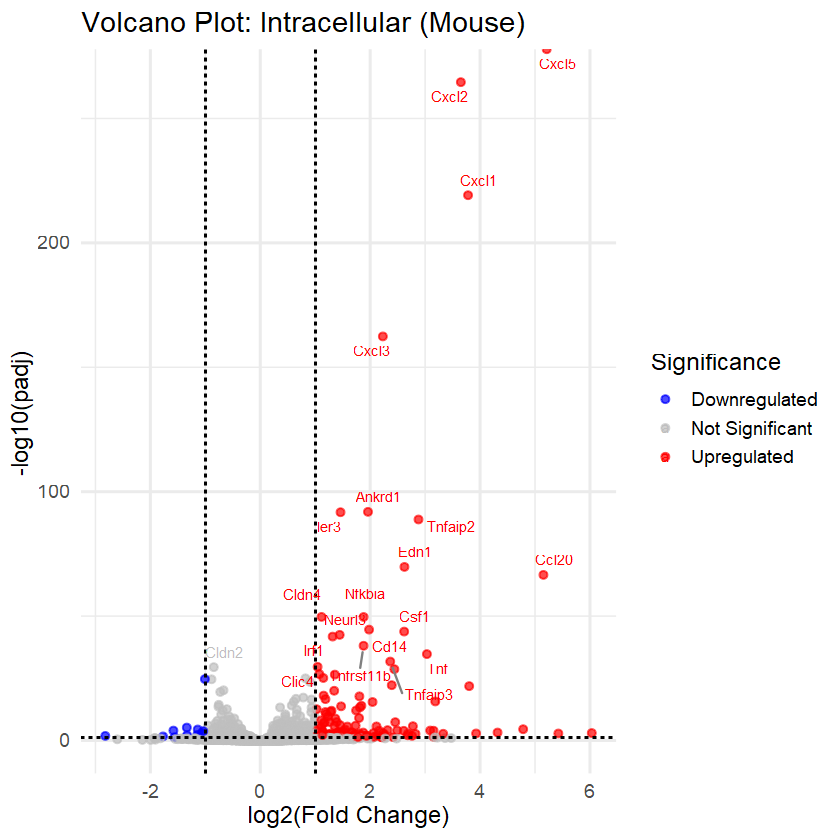

In [15]:
# Draw the volcano plot for mouse data (Intracellular)

# Prepare data
df_Volcano_ms <- res_NT_vs_STm_df_ms_symbol

df_Volcano_ms <- df_Volcano_ms %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange > 1 ~ "Upregulated",
      padj < 0.05 & log2FoldChange < -1 ~ "Downregulated",
      TRUE ~ "Not Significant"
    )
  )

# Draw the volcano plot
library(ggplot2)
library(dplyr)
library(ggrepel)

p_ms <- ggplot(df_Volcano_ms, aes(x = log2FoldChange, y = -log10(padj), color = significance)) +
  geom_point(alpha = 0.7, size = 1.5) +
  scale_color_manual(values = c(
    "Upregulated" = "red",
    "Downregulated" = "blue",
    "Not Significant" = "grey"
  )) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
  labs(
    title = "Volcano Plot: Intracellular (Mouse)",
    x = "log2(Fold Change)",
    y = "-log10(padj)",
    color = "Significance"
  ) +
  theme_minimal(base_size = 14)

# Label the most significant genes
top_genes_ms <- df_Volcano_ms %>%
  arrange(padj) %>%
  filter(!is.na(symbol)) %>%
  head(20)

volcano_intracellular <- p_ms +
  geom_text_repel(
    data = top_genes_ms,
    aes(label = symbol),
    size = 3,
    box.padding = 0.3,
    point.padding = 0.2,
    segment.color = "grey50",
    max.overlaps = Inf
  )

ggsave("Result/Volcano_Intracellular_Mouse.svg", volcano_intracellular, width = 8, height = 8)
ggsave("Result/Volcano_Intracellular_Mouse.pdf", volcano_intracellular, width = 8, height = 8)
volcano_intracellular


Warning message:
"Removed 8185 rows containing missing values or values outside the scale range
(`geom_point()`)."


Warning message:
"Removed 8185 rows containing missing values or values outside the scale range
(`geom_point()`)."


Warning message:
"Removed 8185 rows containing missing values or values outside the scale range
(`geom_point()`)."


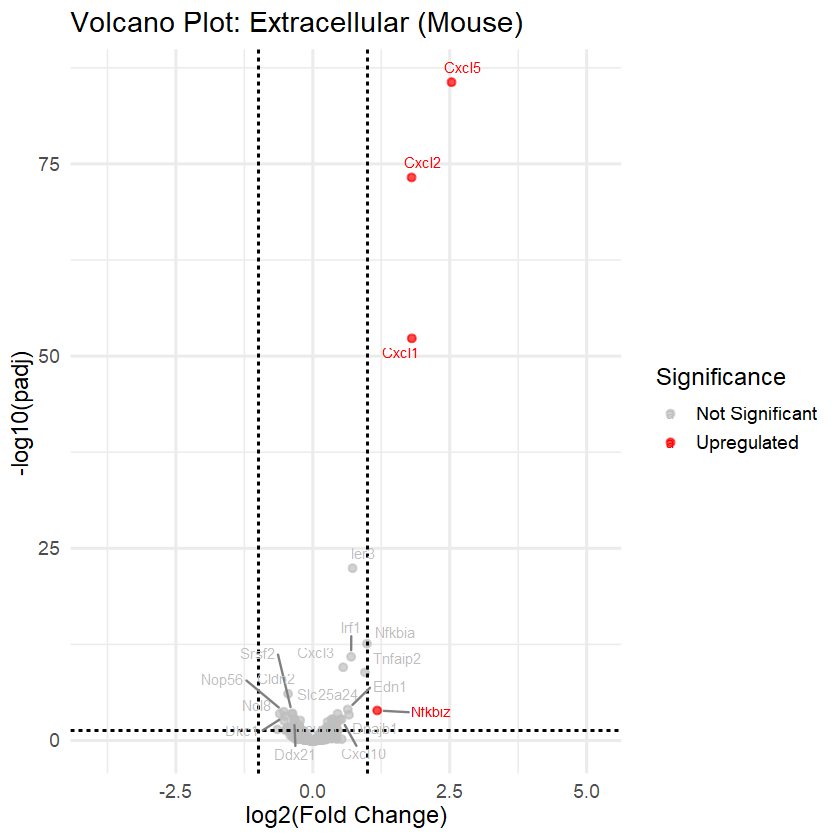

In [16]:
# Draw the volcano plot for mouse data (Extracellular)

# Prepare data
df_Volcano_ms_MBCD <- res_MBCD_vs_STm_MBCD_df_ms_symbol

df_Volcano_ms_MBCD <- df_Volcano_ms_MBCD %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange > 1 ~ "Upregulated",
      padj < 0.05 & log2FoldChange < -1 ~ "Downregulated",
      TRUE ~ "Not Significant"
    )
  )

# Draw the volcano plot
library(ggplot2)
library(dplyr)
library(ggrepel)

p_ms_MBCD <- ggplot(df_Volcano_ms_MBCD, aes(x = log2FoldChange, y = -log10(padj), color = significance)) +
  geom_point(alpha = 0.7, size = 1.5) +
  scale_color_manual(values = c(
    "Upregulated" = "red",
    "Downregulated" = "blue",
    "Not Significant" = "grey"
  )) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
  labs(
    title = "Volcano Plot: Extracellular (Mouse)",
    x = "log2(Fold Change)",
    y = "-log10(padj)",
    color = "Significance"
  ) +
  theme_minimal(base_size = 14)

# Label the most significant genes
top_genes_ms_MBCD <- df_Volcano_ms_MBCD %>%
  arrange(padj) %>%
  filter(!is.na(symbol)) %>%
  head(20)

volcano_extracellular <- p_ms_MBCD +
  geom_text_repel(
    data = top_genes_ms_MBCD,
    aes(label = symbol),
    size = 3,
    box.padding = 0.3,
    point.padding = 0.2,
    segment.color = "grey50",
    max.overlaps = Inf
  )
ggsave("Result/Volcano_Extracellular_Mouse.svg", volcano_extracellular, width = 8, height = 8)
ggsave("Result/Volcano_Extracellular_Mouse.pdf", volcano_extracellular, width = 8, height = 8)
volcano_extracellular


Emrichment analysis

In [17]:
# GSEA input preparation (Mouse: Intracellular)

library(clusterProfiler)
library(org.Mm.eg.db)

# Extract gene list
gene_list_ms <- res_NT_vs_STm_df_ms$log2FoldChange
names(gene_list_ms) <- rownames(res_NT_vs_STm_df_ms)
gene_list_ms <- sort(gene_list_ms, decreasing = TRUE)

# Remove the version suffix from Ensembl IDs
gene_names_clean_ms <- gsub("\\..*", "", names(gene_list_ms))

# Convert Ensembl IDs to Entrez IDs
id_map_ms <- bitr(
  gene_names_clean_ms,
  fromType = "ENSEMBL",
  toType = "ENTREZID",
  OrgDb = org.Mm.eg.db
)

# Match and rename
gene_list_ms <- gene_list_ms[match(id_map_ms$ENSEMBL, names(gene_list_ms))]
names(gene_list_ms) <- id_map_ms$ENTREZID

# Remove NA and duplicate ENTREZ IDs
gene_list_ms <- gene_list_ms[!is.na(names(gene_list_ms))]
gene_list_ms <- gene_list_ms[!duplicated(names(gene_list_ms))]
gene_list_ms <- sort(gene_list_ms, decreasing = TRUE)

# Run GSEA (for mouse)
gsea_res_NTSTM_ms <- gseKEGG(
  geneList = gene_list_ms,
  organism = "mmu",      # <-- change to mouse
  minGSSize = 10,
  maxGSSize = 500,
  pvalueCutoff = 0.1,
  verbose = FALSE
)

'select()' returned 1:many mapping between keys and columns



Warning message in bitr(gene_names_clean_ms, fromType = "ENSEMBL", toType = "ENTREZID", :
"4.41% of input gene IDs are fail to map..."


Reading KEGG annotation online: "https://rest.kegg.jp/link/mmu/pathway"...



Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/mmu"...



Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.42% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA."


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation."


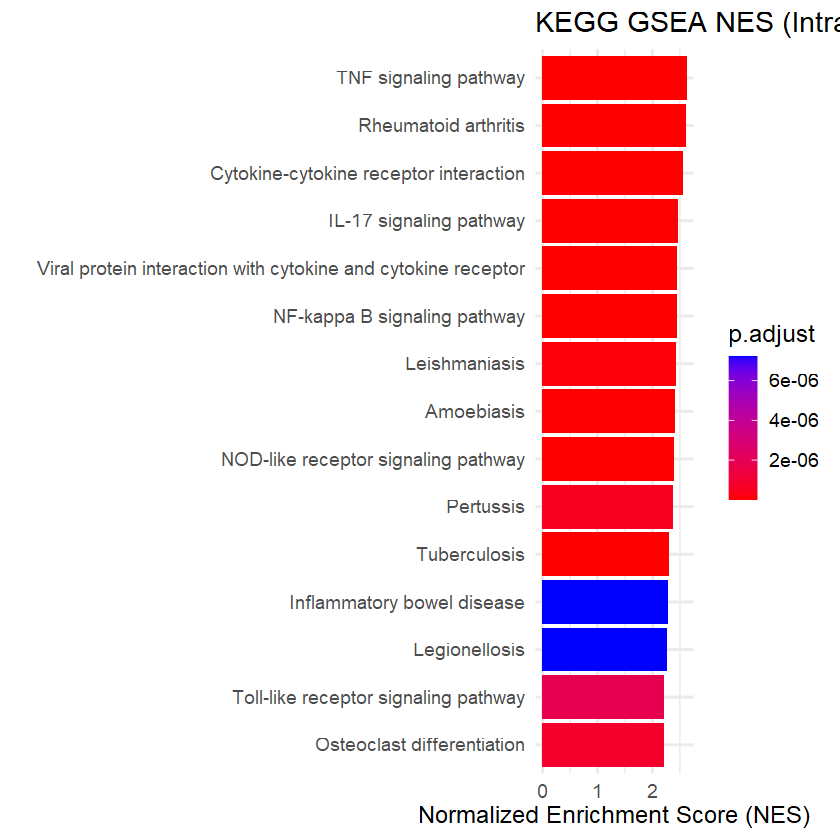

In [18]:
# NES bar plot for KEGG GSEA results (Intracellular)
gsea_df_NTSTM <- as.data.frame(gsea_res_NTSTM_ms)
gsea_df_NTSTM <- gsea_df_NTSTM[order(gsea_df_NTSTM$NES, decreasing = TRUE), ]
top15_NTSTM <- head(gsea_df_NTSTM, 15)
ggplot(top15_NTSTM, aes(x = reorder(Description, NES), y = NES, fill = p.adjust)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "red", high = "blue", name = "p.adjust") +
  labs(title = "KEGG GSEA NES (Intracellular, Mouse)", x = "", y = "Normalized Enrichment Score (NES)") +
  theme_minimal(base_size = 14)
ggsave("Result/KEGG_NES_Intracellular_Mouse.svg", width = 10, height = 8)
ggsave("Result/KEGG_NES_Intracellular_Mouse.pdf", width = 10, height = 8)


In [19]:
# GSEA input preparation (Mouse: Extracellular)

library(clusterProfiler)
library(org.Mm.eg.db)

# Extract gene list
gene_list_ms_MBCD <- res_MBCD_vs_STm_MBCD_df_ms$log2FoldChange
names(gene_list_ms_MBCD) <- rownames(res_MBCD_vs_STm_MBCD_df_ms)
gene_list_ms_MBCD <- sort(gene_list_ms_MBCD, decreasing = TRUE)

# Remove the version suffix from Ensembl IDs
gene_names_clean_ms_MBCD <- gsub("\\..*", "", names(gene_list_ms_MBCD))

# Convert Ensembl IDs to Entrez IDs
id_map_ms_MBCD <- bitr(
  gene_names_clean_ms_MBCD,
  fromType = "ENSEMBL",
  toType = "ENTREZID",
  OrgDb = org.Mm.eg.db
)

# Match and rename
gene_list_ms_MBCD <- gene_list_ms_MBCD[match(id_map_ms_MBCD$ENSEMBL, names(gene_list_ms_MBCD))]
names(gene_list_ms_MBCD) <- id_map_ms_MBCD$ENTREZID

# Remove NA and duplicate ENTREZ IDs
gene_list_ms_MBCD <- gene_list_ms_MBCD[!is.na(names(gene_list_ms_MBCD))]
gene_list_ms_MBCD <- gene_list_ms_MBCD[!duplicated(names(gene_list_ms_MBCD))]
gene_list_ms_MBCD <- sort(gene_list_ms_MBCD, decreasing = TRUE)

# Run GSEA (for mouse)
gsea_res_MBCD_ms <- gseKEGG(
  geneList = gene_list_ms_MBCD,
  organism = "mmu",      # <-- Mouse KEGG organism code
  minGSSize = 10,
  maxGSSize = 500,
  pvalueCutoff = 0.1,
  verbose = FALSE
)

'select()' returned 1:many mapping between keys and columns



Warning message in bitr(gene_names_clean_ms_MBCD, fromType = "ENSEMBL", toType = "ENTREZID", :
"4.41% of input gene IDs are fail to map..."


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.43% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."


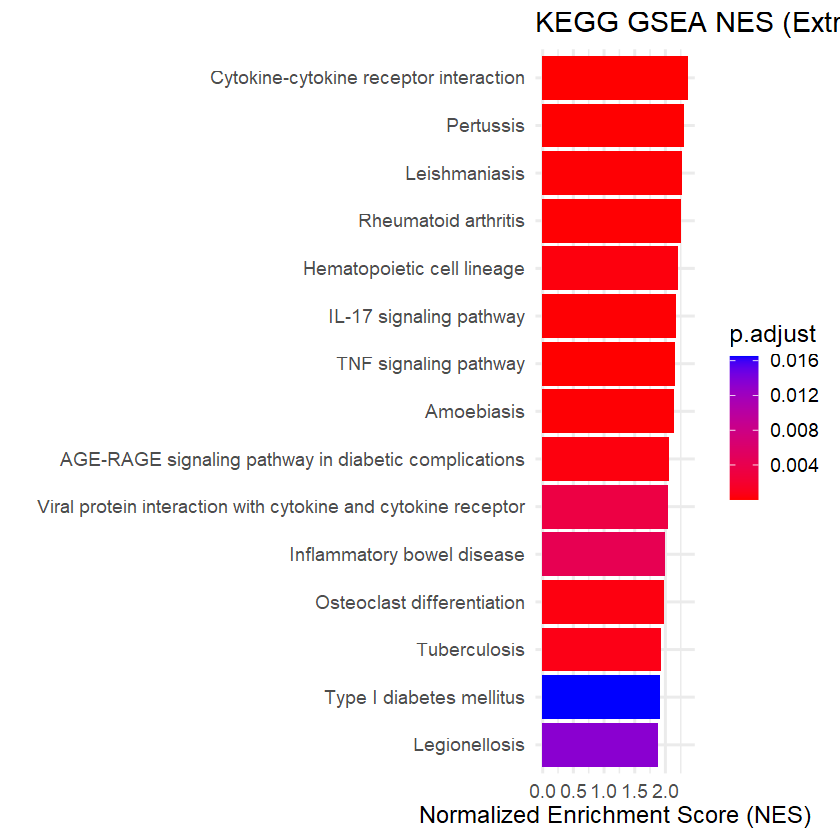

In [20]:
# NES bar plot for KEGG GSEA results (Extracellular)
gsea_df_MBCD <- as.data.frame(gsea_res_MBCD_ms)
gsea_df_MBCD <- gsea_df_MBCD[order(gsea_df_MBCD$NES, decreasing = TRUE), ]
top15_MBCD <- head(gsea_df_MBCD, 15)
ggplot(top15_MBCD, aes(x = reorder(Description, NES), y = NES, fill = p.adjust)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "red", high = "blue", name = "p.adjust") +
  labs(title = "KEGG GSEA NES (Extracellular, Mouse)", x = "", y = "Normalized Enrichment Score (NES)") +
  theme_minimal(base_size = 14)
ggsave("Result/KEGG_NES_Extracellular_Mouse.svg", width = 10, height = 8)
ggsave("Result/KEGG_NES_Extracellular_Mouse.pdf", width = 10, height = 8)


In [21]:
library(enrichplot)

# Plot GSEA enrichment for NF-kappa B signaling pathway (Mouse)

# Intracellular
svglite::svglite("Result/GSEA_NFkB_Intracellular_Mouse.svg", width = 8, height = 6)
gseaplot2(
  gsea_res_NTSTM_ms,
  geneSetID = which(gsea_res_NTSTM_ms@result$Description == "NF-kappa B signaling pathway")[1],
  title = "NF-κB signaling pathway (Intracellular, Mouse)"
)

dev.off()

# Extracellular
svglite::svglite("Result/GSEA_NFkB_Extracellular_Mouse.svg", width = 8, height = 6)
gseaplot2(
  gsea_res_MBCD_ms,
  geneSetID = which(gsea_res_MBCD_ms@result$Description == "NF-kappa B signaling pathway")[1],
  title = "NF-κB signaling pathway (Extracellular, Mouse)"
)
dev.off()


agg_record_2ba01a611ca1 
                      2

agg_record_2ba01a611ca1 
                      2

Heat map and Venn diagram

In [22]:
# Load required packages
library(DESeq2)
library(VennDiagram)
library(pheatmap)
library(dplyr)
library(grid)

# VST conversion
vsd_ms <- vst(dds_ms, blind = FALSE)

# Identify significantly enriched genes (Mouse)

# Intracellular
sig_intracellular_degs_df_ms <- res_NT_vs_STm_df_ms_symbol %>%
  filter(padj < 0.05, abs(log2FoldChange) > 1, !is.na(symbol))

# Extracellular
sig_extracellular_degs_df_ms <- res_MBCD_vs_STm_MBCD_df_ms_symbol %>%
  filter(padj < 0.05, abs(log2FoldChange) > 1, !is.na(symbol))

# Take the gene symbols
intracellular_symbols_ms <- sig_intracellular_degs_df_ms$symbol
extracellular_symbols_ms <- sig_extracellular_degs_df_ms$symbol

# Create gene list for Venn diagram
gene_lists_for_venn_ms <- list(
  `Extracellular` = extracellular_symbols_ms,
  `Intracellular` = intracellular_symbols_ms
)

# Draw the Venn diagram
venn_plot_ms <- venn.diagram(
  x = gene_lists_for_venn_ms,
  filename = NULL,
  output = FALSE,
  imagetype = "png",
  height = 800,
  width = 800,
  resolution = 300,
  compression = "lzw",
  lwd = 2,
  lty = 'blank',
  fill = c("#440154ff", "#21908dff"),
  cex = 0.8,
  fontface = "bold",
  cat.cex = 0.8,
  cat.fontface = "bold",
  cat.default.pos = "outer",
  cat.dist = c(0.055, 0.055)
)

# Display Venn diagram
svglite::svglite("Result/Venn_Diagram_Mouse.svg", width = 8, height = 8)
grid.draw(venn_plot_ms)

dev.off()

# Output gene list used for Venn
sig_intracellular_degs_df_ms
sig_extracellular_degs_df_ms

Warning message:
"package 'VennDiagram' was built under R version 4.5.3"


Loading required package: grid



Loading required package: futile.logger



Warning message:
"package 'futile.logger' was built under R version 4.5.3"


agg_record_2ba034564d39 
                      2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ENSEMBL,symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSMUSG00000002983,117.273444,1.233513,0.17331520,7.117167,1.101682e-12,1.883029e-10,ENSMUSG00000002983,Relb
ENSMUSG00000003541,2834.340412,1.460488,0.07034969,20.760402,9.873671e-96,1.828275e-92,ENSMUSG00000003541,Ier3
ENSMUSG00000009772,85.507414,1.059998,0.18928772,5.599930,2.144383e-08,1.968934e-06,ENSMUSG00000009772,Nuak2
ENSMUSG00000010651,30.238720,1.095419,0.35302852,3.102919,1.916221e-03,3.363225e-02,ENSMUSG00000010651,Acaa1b
ENSMUSG00000013076,12.660769,2.234082,0.52863125,4.226163,2.377094e-05,1.027033e-03,ENSMUSG00000013076,Amotl1
ENSMUSG00000013089,33.336580,-1.580854,0.33026424,-4.786633,1.696029e-06,1.029666e-04,ENSMUSG00000013089,Etv5
ENSMUSG00000013846,128.379299,1.170755,0.18654828,6.275880,3.476632e-10,4.491323e-08,ENSMUSG00000013846,St3gal1
ENSMUSG00000014599,140.946698,2.618551,0.18100004,14.467131,1.954553e-47,1.670391e-44,ENSMUSG00000014599,Csf1
ENSMUSG00000015533,92.109461,1.391837,0.22056043,6.310455,2.782163e-10,3.724075e-08,ENSMUSG00000015533,Itga2


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ENSEMBL,symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSMUSG00000029371,2260.4294,2.532876,0.12603682,20.096319,7.947482e-90,2.324638e-86,ENSMUSG00000029371,Cxcl5
ENSMUSG00000029380,710.6391,1.808192,0.11466421,15.769457,5.048169e-56,4.921965e-53,ENSMUSG00000029380,Cxcl1
ENSMUSG00000035356,212.8929,1.176280,0.23345324,5.038609,4.689276e-07,1.246921e-04,ENSMUSG00000035356,Nfkbiz
ENSMUSG00000058427,760.0260,1.803531,0.09702045,18.589179,3.931487e-77,5.749799e-74,ENSMUSG00000058427,Cxcl2


Heat map of NF-kapa B

In [23]:
# BiocManager::install("KEGGREST")
library(KEGGREST)
library(pheatmap)
library(AnnotationDbi)
library(org.Hs.eg.db)

In [24]:
# Get the NF-kapaB information
nfkb_pathway_info <- keggGet("mmu04064")[[1]]

In [25]:
#take the id from the information pack
nfkb_entrez_ids <- nfkb_pathway_info$GENE[seq(1, length(nfkb_pathway_info$GENE), 2)]

In [26]:
#Remove the description Information
nfkb_entrez_ids <- sapply(strsplit(nfkb_entrez_ids, ";"), `[`, 1)

In [27]:
# Change the ID
id_conversion <- AnnotationDbi::select(
  org.Mm.eg.db,
  keys = nfkb_entrez_ids,
  keytype = "ENTREZID",
  columns = "ENSEMBL"
)
nfkb_ensembl_ids <- unique(na.omit(id_conversion$ENSEMBL))

'select()' returned 1:1 mapping between keys and columns



In [28]:
# 找出显著差异基因
sig_degs_nt_stm <- subset(res_NT_vs_STm_df_ms, padj < 0.05)
sig_degs_mbcd <- subset(res_MBCD_vs_STm_MBCD_df_ms, padj < 0.05)
sig_ensembl_ids <- unique(c(rownames(sig_degs_nt_stm), rownames(sig_degs_mbcd)))

core_nfkb_degs_ensembl <- intersect(nfkb_ensembl_ids, sig_ensembl_ids)


# VST 归一化
vsd_ms <- vst(dds_ms, blind = FALSE)
vst_counts <- assay(vsd_ms)

# 额外想展示的基因（Symbol）
extra_genes <- c("Zc3h12a", "Il6", "Lcn2", "Il1a")  # 注意小鼠基因名首字母大写

# SYMBOL → ENSEMBL ID 映射
extra_ensembl_ids <- mapIds(
  org.Mm.eg.db,
  keys = extra_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "first"
)

# 合并目标基因
genes_to_plot <- unique(c(core_nfkb_degs_ensembl, extra_ensembl_ids))

# 取出表达矩阵中对应基因
heatmap_matrix <- vst_counts[intersect(genes_to_plot, rownames(vst_counts)), ]

# 将 ENSEMBL ID 转换为基因 SYMBOL
gene_symbols <- mapIds(
  org.Mm.eg.db,
  keys = rownames(heatmap_matrix),
  column = "SYMBOL",
  keytype = "ENSEMBL",
  multiVals = "first"
)

# 去除无法映射的行
heatmap_matrix <- heatmap_matrix[!is.na(gene_symbols), ]
rownames(heatmap_matrix) <- gene_symbols[!is.na(gene_symbols)]


# 绘制热图
pheatmap(
  heatmap_matrix,
  fontsize_row = 8,
  fontsize_col = 10,
  annotation_col = coldata_ms,  # 对应小鼠分组信息
  scale = "row",
  cluster_rows = TRUE,
  cluster_cols = TRUE
  , filename = "Result/Heatmap_NFkB_Mouse.pdf"
)


'select()' returned 1:1 mapping between keys and columns



'select()' returned 1:1 mapping between keys and columns



In [29]:
# ---------------------------------------------
# Check the expression of selected genes in two comparisons
# ---------------------------------------------

# Input: target genes of interest
target_genes <- c("Zc3h12a", "Il6", "Lcn2", "Il1a", "Tnf")  # change to any genes of interest

# Define the DESeq2 result data frames for each comparison
contrast_info <- list(
  "Intracellular" = res_NT_vs_STm_df_ms,
  "Extracellular" = res_MBCD_vs_STm_MBCD_df_ms
)

# ---------------------------------------------
# Convert SYMBOL to ENSEMBL IDs (mouse database)
# ---------------------------------------------
ensembl_ids <- mapIds(
  org.Mm.eg.db,
  keys = target_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "first"
)
ensembl_ids <- na.omit(ensembl_ids)  # remove missing mappings

# Create a lookup table to map ENSEMBL back to SYMBOL
symbol_lookup <- names(ensembl_ids)
names(symbol_lookup) <- ensembl_ids


# ---------------------------------------------
# Extract expression results for the selected genes
# ---------------------------------------------
extract_results <- function(res_df, comparison_name) {
  df <- as.data.frame(res_df)
  df <- df[rownames(df) %in% ensembl_ids, ]  # keep only target genes
  df$symbol <- symbol_lookup[rownames(df)]   # add gene symbols
  df$comparison <- comparison_name           # label comparison
  return(df[, c("symbol", "log2FoldChange", "padj", "comparison")])
}

# Apply the extraction function to each comparison
results_list <- lapply(names(contrast_info), function(name) {
  extract_results(contrast_info[[name]], name)
})

# Combine all results into one table
combined_results <- do.call(rbind, results_list)

# ---------------------------------------------
# Output summary table (sorted by gene and p-value)
# ---------------------------------------------
final_summary <- combined_results %>%
  arrange(symbol, padj)

# View the summary
final_summary


'select()' returned 1:1 mapping between keys and columns



,symbol,log2FoldChange,padj,comparison
,<chr>,<dbl>,<dbl>,<chr>
ENSMUSG00000027399,Il1a,5.4244306,1.509151e-03,Intracellular
ENSMUSG000000273991,Il1a,5.1750800,NA,Extracellular
ENSMUSG00000026822,Lcn2,4.7841117,2.924230e-05,Intracellular
ENSMUSG000000268221,Lcn2,0.2815132,NA,Extracellular
ENSMUSG00000024401,Tnf,3.0325231,1.878942e-35,Intracellular
ENSMUSG000000244011,Tnf,1.4785904,NA,Extracellular
ENSMUSG00000042677,Zc3h12a,3.8017637,1.420622e-22,Intracellular
ENSMUSG000000426771,Zc3h12a,2.7790396,NA,Extracellular


PPI analysis

In [30]:
# --- Example 1: Extract leading-edge genes of the NF-kappa B signaling pathway (Mouse) ---

# 1. Check the GSEA results for Intracellular to identify the exact pathway description
# head(as.data.frame(gsea_res_NTSTM_ms))
# Assume the pathway name is "NF-kappa B signaling pathway"

# 2. Extract the core enrichment (leading-edge) genes for the selected pathway
pathway_name <- "NF-kappa B signaling pathway"
gsea_result_df <- as.data.frame(gsea_res_NTSTM_ms)

# Find the core_enrichment field for the selected pathway
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# core_enrichment_ids is a string of Entrez IDs separated by "/"
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 3. Convert Entrez IDs to gene symbols (use mouse annotation database)
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 4. Print the results
cat("Leading-edge genes for '", pathway_name, "' in (Intracellular):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'NF-kappa B signaling pathway' in (Intracellular):


14825       20310       20303       22329       21926       21929 
    "Cxcl1"     "Cxcl2"      "Ccl4"     "Vcam1"       "Tnf"   "Tnfaip3" 
     330122       12475       18035       21934       19225       18792 
    "Cxcl3"      "Cd14"    "Nfkbia" "Tnfrsf11a"     "Ptgs2"      "Plau" 
      19698       17060       22031       18034       11796       18033 
     "Relb"      "Blnk"     "Traf3"     "Nfkb2"     "Birc3"     "Nfkb1" 
     234779       74256       22033       16803       15894       17087 
    "Plcg2"      "Cyld"     "Traf5"       "Lbp"     "Icam1"      "Ly96" 
     333654       22030       16177       19697       12633       17874 
 "Ppp1r13l"     "Traf2"     "Il1r1"      "Rela"     "Cflar"     "Myd88" 
      12042 
    "Bcl10"

In [31]:
# --- Example 2: Extract leading-edge genes of the NF-kappa B signaling pathway (Mouse, Extracellular) ---

# 1. Define the target pathway
pathway_name <- "NF-kappa B signaling pathway"

# 2. Load the GSEA results for the Extracellular comparison
gsea_result_df <- as.data.frame(gsea_res_MBCD_ms)

# 3. Find the core_enrichment genes (Entrez IDs) corresponding to the selected pathway
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 4. Split the string into individual Entrez IDs
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 5. Convert Entrez IDs to gene symbols (make sure org.Mm.eg.db is loaded)
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 6. Print the results
cat("Leading-edge genes for '", pathway_name, "' in (Extracellular):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'NF-kappa B signaling pathway' in (Extracellular):


14825       20310       21926       22329       18035       21929 
    "Cxcl1"     "Cxcl2"       "Tnf"     "Vcam1"    "Nfkbia"   "Tnfaip3" 
     170720       19698       12475      330122      333654       18792 
   "Card14"      "Relb"      "Cd14"     "Cxcl3"  "Ppp1r13l"      "Plau" 
      18033       21934       66724      106759      234779       11796 
    "Nfkb1" "Tnfrsf11a"      "Tab3"    "Ticam1"     "Plcg2"     "Birc3" 
      19225      111173       12633       17873       53859       12675 
    "Ptgs2"      "Erc1"     "Cflar"   "Gadd45b"   "Map3k14"      "Chuk" 
      17087       19697       12042       57913       15894       12995 
     "Ly96"      "Rela"     "Bcl10"     "Pidd1"     "Icam1"   "Csnk2a1" 
      21937       18034       26409 
 "Tnfrsf1a"     "Nfkb2"    "Map3k7"

In [32]:
# --- Check NF-kappa B leading-edge genes expression in two mouse comparisons ---

# 1. Define the target genes (intersection of both NF-kappa B leading-edge sets)
target_genes <- c(
  "Cxcl1", "Cxcl2", "Tnf", "Vcam1", "Nfkbia", "Tnfaip3", "Relb", "Cd14",
  "Cxcl3", "Ppp1r13l", "Plau", "Nfkb1", "Tnfrsf11a", "Plcg2", "Birc3",
  "Ptgs2", "Cflar", "Ly96", "Rela", "Bcl10", "Icam1", "Nfkb2"
)

# 2. Define the DESeq2 result data frames for each comparison (mouse)
contrast_info <- list(
  "Intracellular" = res_NT_vs_STm_df_ms,
  "Extracellular" = res_MBCD_vs_STm_MBCD_df_ms
)

# 3. Convert SYMBOL to ENSEMBL ID (mouse database)
ensembl_ids <- mapIds(
  org.Mm.eg.db,
  keys = target_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "first"
)
ensembl_ids <- na.omit(ensembl_ids)

# Create a lookup table for ENSEMBL → SYMBOL conversion
symbol_lookup <- names(ensembl_ids)
names(symbol_lookup) <- ensembl_ids


# 4. Define a function to extract results for target genes
extract_results <- function(res_df, comparison_name) {
  df <- as.data.frame(res_df)
  df <- df[rownames(df) %in% ensembl_ids, ]  # filter for target genes
  df$symbol <- symbol_lookup[rownames(df)]   # add gene symbol
  df$comparison <- comparison_name           # label the comparison
  return(df[, c("symbol", "log2FoldChange", "padj", "comparison")])
}

# 5. Apply extraction function to each comparison
results_list <- lapply(names(contrast_info), function(name) {
  extract_results(contrast_info[[name]], name)
})

# 6. Combine results into a single table
combined_results <- do.call(rbind, results_list)

# 7. Sort by gene symbol and adjusted p-value
final_summary <- combined_results %>%
  arrange(symbol, padj)

# 8. Print and export results
final_summary
write.csv(final_summary, "final_summary_of_NFKB_MOUSE.csv", row.names = TRUE)


'select()' returned 1:1 mapping between keys and columns



,symbol,log2FoldChange,padj,comparison
,<chr>,<dbl>,<dbl>,<chr>
ENSMUSG00000028191,Bcl10,0.4176443,6.525194e-03,Intracellular
ENSMUSG000000281911,Bcl10,0.2013781,3.999054e-01,Extracellular
ENSMUSG00000032000,Birc3,0.8957448,1.865020e-02,Intracellular
ENSMUSG000000320001,Birc3,0.3465429,NA,Extracellular
ENSMUSG00000051439,Cd14,1.9799886,2.698908e-45,Intracellular
ENSMUSG000000514391,Cd14,0.6858073,NA,Extracellular
ENSMUSG00000026031,Cflar,0.4423017,3.527074e-02,Intracellular
ENSMUSG000000260311,Cflar,0.2737388,NA,Extracellular
ENSMUSG00000029380,Cxcl1,3.7813364,7.136376e-220,Intracellular


Cytokine and Cytokine R signaling pathway analyse

In [33]:
# --- 提取 Intracellular (mouse) 中的 Cytokine-cytokine receptor interaction 通路领头基因 ---

# 1. 指定通路名称与结果对象
pathway_name <- "Cytokine-cytokine receptor interaction"
gsea_result_df <- as.data.frame(gsea_res_NTSTM_ms)

# 2. 找到该通路对应的 core_enrichment 基因 ID（Entrez ID）
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 如果没有匹配结果，提示用户
if (length(core_enrichment_ids) == 0) {
  stop(paste("Pathway", pathway_name, "not found in gsea_res_NTSTM_ms"))
}

# 3. 将 core_enrichment 字符串按 "/" 分割为 Entrez ID 向量
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 4. 将 Entrez ID 转换为基因符号（小鼠版）
library(org.Mm.eg.db)
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 5. 打印结果
cat("Leading-edge genes for '", pathway_name, "' in (Intracellular, mouse):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'Cytokine-cytokine receptor interaction' in (Intracellular, mouse):


16175       20311       20297       14825       20310       20303 
     "Il1a"     "Cxcl5"     "Ccl20"     "Cxcl1"     "Cxcl2"      "Ccl4" 
      21926       12981       12977       22035      330122       18383 
      "Tnf"      "Csf2"      "Csf1"   "Tnfsf10"     "Cxcl3" "Tnfrsf11b" 
      16878       20312       16168       21934       57349       15945 
      "Lif"    "Cx3cl1"      "Il15" "Tnfrsf11a"      "Ppbp"    "Cxcl10" 
      21938       21808       15979       18414       66102       16178 
 "Tnfrsf1b"     "Tgfb2"    "Ifngr1"      "Osmr"    "Cxcl16"     "Il1r2" 
      15976       12159       16173       14102       13857      242700 
   "Ifnar2"      "Bmp4"      "Il18"       "Fas"      "Epor"    "Ifnlr1" 
      57914       12161       20304       23886 
    "Crlf2"      "Bmp6"      "Ccl5"     "Gdf15"

In [34]:
# --- 提取 Extracellular (mouse) 中的 Cytokine-cytokine receptor interaction 通路领头基因 ---

# 1. 指定通路名称与结果对象
pathway_name <- "Cytokine-cytokine receptor interaction"
gsea_result_df <- as.data.frame(gsea_res_MBCD_ms)

# 2. 找到该通路对应的 core_enrichment 基因 ID（Entrez ID）
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 如果没有匹配结果，提示用户
if (length(core_enrichment_ids) == 0) {
  stop(paste("Pathway", pathway_name, "not found in gsea_res_MBCDSTM_ms"))
}

# 3. 将 core_enrichment 字符串按 "/" 分割为 Entrez ID 向量
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 4. 将 Entrez ID 转换为基因符号（小鼠版）
library(org.Mm.eg.db)
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 5. 打印结果
cat("Leading-edge genes for '", pathway_name, "' in (Extracellular, mouse):\n", sep = "")
leading_edge_symbols

'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'Cytokine-cytokine receptor interaction' in (Extracellular, mouse):


16175       20311       14825       20310       18414       21926 
     "Il1a"     "Cxcl5"     "Cxcl1"     "Cxcl2"      "Osmr"       "Tnf" 
      20297       13857       12981       50905       12159       21942 
    "Ccl20"      "Epor"      "Csf2"    "Il17rb"      "Bmp4"   "Tnfrsf9" 
      12977       16878      330122       15945       16169       16178 
     "Csf1"       "Lif"     "Cxcl3"    "Cxcl10"    "Il15ra"     "Il1r2" 
      21934       18383       22035       21803       21936       16155 
"Tnfrsf11a" "Tnfrsf11b"   "Tnfsf10"     "Tgfb1"  "Tnfrsf18"    "Il10rb" 
      15979       12156       12168      242700       16164       83430 
   "Ifngr1"      "Bmp2"     "Bmpr2"    "Ifnlr1"   "Il13ra1"     "Il23a" 
      77125      100532       20304       21808       23886       16195 
     "Il33"     "Rell1"      "Ccl5"     "Tgfb2"     "Gdf15"     "Il6st" 
      66102       57914 
   "Cxcl16"     "Crlf2"

'select()' returned 1:1 mapping between keys and columns



'select()' returned 1:1 mapping between keys and columns



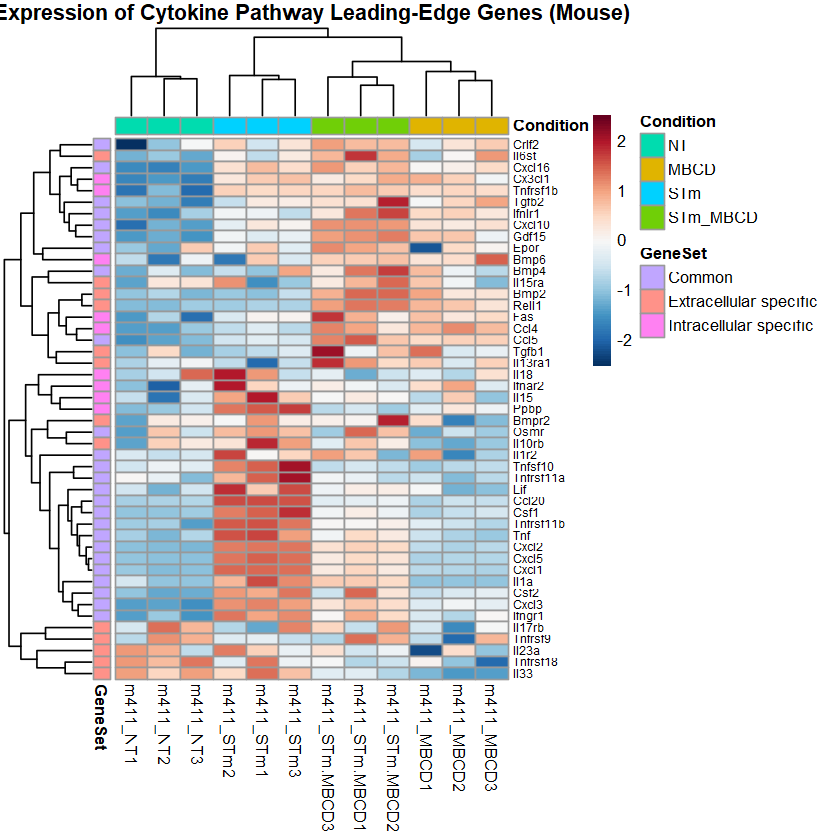

In [35]:
# --- Cytokine–cytokine receptor interaction pathway (Mouse) heatmap ---

library(pheatmap)
library(RColorBrewer)
library(org.Mm.eg.db)

# 1. 定义你提供的两组领头基因
genes_nt_vs_stm <- c(
  'Il1a','Cxcl5','Ccl20','Cxcl1','Cxcl2','Ccl4','Tnf','Csf2','Csf1','Tnfsf10',
  'Cxcl3','Tnfrsf11b','Lif','Cx3cl1','Il15','Tnfrsf11a','Ppbp','Cxcl10','Tnfrsf1b',
  'Tgfb2','Ifngr1','Osmr','Cxcl16','Il1r2','Ifnar2','Bmp4','Il18','Fas','Epor',
  'Ifnlr1','Crlf2','Bmp6','Ccl5','Gdf15'
)

genes_mbcd_vs_mbcdstm <- c(
  'Il1a','Cxcl5','Cxcl1','Cxcl2','Osmr','Tnf','Ccl20','Epor','Csf2','Il17rb',
  'Bmp4','Tnfrsf9','Csf1','Lif','Cxcl3','Cxcl10','Il15ra','Il1r2','Tnfrsf11a',
  'Tnfrsf11b','Tnfsf10','Tgfb1','Tnfrsf18','Il10rb','Ifngr1','Bmp2','Bmpr2',
  'Ifnlr1','Il13ra1','Il23a','Il33','Rell1','Ccl5','Tgfb2','Gdf15','Il6st',
  'Cxcl16','Crlf2'
)

# 2. 合并并获取所有唯一基因
all_genes <- unique(c(genes_nt_vs_stm, genes_mbcd_vs_mbcdstm))

# 3. 转换为 Ensembl ID（使用 org.Mm.eg.db）
ensembl_ids_to_plot_list <- mapIds(
  org.Mm.eg.db,
  keys = all_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "list"
)

# 展开并过滤掉 NA
ensembl_ids_to_plot <- unlist(na.omit(ensembl_ids_to_plot_list))

# 4. 从 VST 转换后的表达矩阵中提取数据（小鼠版）
# ⚠️ 记忆中的变量：vsd_ms 和 dds_ms
vst_counts <- assay(vsd_ms)

# 仅保留表达矩阵中存在的基因
ensembl_ids_in_vst <- intersect(ensembl_ids_to_plot, rownames(vst_counts))
heatmap_matrix <- vst_counts[ensembl_ids_in_vst, ]

# 5. 将行名转换回基因符号以显示
gene_symbols_for_rows <- mapIds(
  org.Mm.eg.db,
  keys = rownames(heatmap_matrix),
  column = "SYMBOL",
  keytype = "ENSEMBL",
  multiVals = "first"
)
rownames(heatmap_matrix) <- gene_symbols_for_rows

# 6. 创建注释信息
annotation_col <- as.data.frame(colData(dds_ms)[, "condition_ms", drop = FALSE])
colnames(annotation_col) <- "Condition"

# 定义共同与特异基因
common_genes <- intersect(genes_nt_vs_stm, genes_mbcd_vs_mbcdstm)
unique_nt_stm <- setdiff(genes_nt_vs_stm, common_genes)
unique_mbcd <- setdiff(genes_mbcd_vs_mbcdstm, common_genes)

# 仅为热图中实际出现的基因添加注释
heatmap_genes <- rownames(heatmap_matrix)
gene_set_info <- rep("Unknown", length(heatmap_genes))
names(gene_set_info) <- heatmap_genes

gene_set_info[heatmap_genes %in% common_genes] <- "Common"
gene_set_info[heatmap_genes %in% unique_nt_stm] <- "Intracellular specific"
gene_set_info[heatmap_genes %in% unique_mbcd] <- "Extracellular specific"

annotation_row <- data.frame(GeneSet = factor(gene_set_info))
rownames(annotation_row) <- heatmap_genes

# 7. 绘制热图
pheatmap(
  heatmap_matrix,
  main = "Expression of Cytokine Pathway Leading-Edge Genes (Mouse)",
  annotation_col = annotation_col,
  annotation_row = annotation_row,
  scale = "row",          # 按行 Z-score 标准化
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = TRUE,
  fontsize_row = 7,
  fontsize_col = 10,
  color = colorRampPalette(rev(brewer.pal(11, "RdBu")))(100)
)

TNF Pathway

In [36]:
# --- 从 Intracellular (Mouse) GSEA 结果中提取 TNF signaling pathway 的领头基因 ---

# 设定目标通路
pathway_name <- "TNF signaling pathway"

# 转换 GSEA 结果为数据框（小鼠变量）
gsea_result_df <- as.data.frame(gsea_res_NTSTM_ms)

# 找到该通路的 core_enrichment 基因 ID（Entrez ID 格式）
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 拆分字符串，提取单个 Entrez ID
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 将 Entrez ID 转换为基因符号 SYMBOL（使用小鼠数据库）
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 打印结果
cat("Leading-edge genes for '", pathway_name, "' in (Intracellular, mouse):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'TNF signaling pathway' in (Intracellular, mouse):


20311      20297     257632      14825      20310      22329      21926 
   "Cxcl5"    "Ccl20"     "Nod2"    "Cxcl1"    "Cxcl2"    "Vcam1"      "Tnf" 
     26410      12981      13614      12977      21929     330122      18035 
  "Map3k8"     "Csf2"     "Edn1"     "Csf1"  "Tnfaip3"    "Cxcl3"   "Nfkbia" 
     16878      20312      16168      19225      15945      16362      21938 
     "Lif"   "Cx3cl1"     "Il15"    "Ptgs2"   "Cxcl10"     "Irf1" "Tnfrsf1b" 
     12051      19094      73086      22031      11796      18033      15953 
    "Bcl3"   "Mapk11"  "Rps6ka5"    "Traf3"    "Birc3"    "Nfkb1"    "Ifi47" 
     14102      74256      16477      22033      15894 
     "Fas"     "Cyld"     "Junb"    "Traf5"    "Icam1"

In [37]:
# --- 从 Extracellular (Mouse) GSEA 结果中提取 TNF signaling pathway 的领头基因 ---

pathway_name <- "TNF signaling pathway"
gsea_result_df <- as.data.frame(gsea_res_MBCD_ms)

core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

leading_edge_symbols <- mapIds(
  org.Mm.eg.db,
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

cat("Leading-edge genes for '", pathway_name, "' in (Extracellular, mouse):\n", sep = "")
leading_edge_symbols

'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'TNF signaling pathway' in (Extracellular, mouse):


20311     14825     20310    257632     21926     20297     22329     18035 
  "Cxcl5"   "Cxcl1"   "Cxcl2"    "Nod2"     "Tnf"   "Ccl20"   "Vcam1"  "Nfkbia" 
    12981     21929     12977     16362     16878     13614    330122     15945 
   "Csf2" "Tnfaip3"    "Csf1"    "Irf1"     "Lif"    "Edn1"   "Cxcl3"  "Cxcl10" 
    18033     26419     12051     26399     66724     12369     16477     67384 
  "Nfkb1"   "Mapk8"    "Bcl3"  "Map2k6"    "Tab3"   "Casp7"    "Junb"    "Bag4" 
   217344     11796    208647     26410     19225     26417     20304     12633 
 "Rhbdf2"   "Birc3" "Creb3l2"  "Map3k8"   "Ptgs2"   "Mapk3"    "Ccl5"   "Cflar" 
    69601     53859     26395     18710     16168     18708     12675     14102 
 "Dab2ip" "Map3k14"  "Map2k1"  "Pik3r3"    "Il15"  "Pik3r1"    "Chuk"     "Fas" 
    19697 
   "Rela"

'select()' returned 1:many mapping between keys and columns



'select()' returned 1:1 mapping between keys and columns



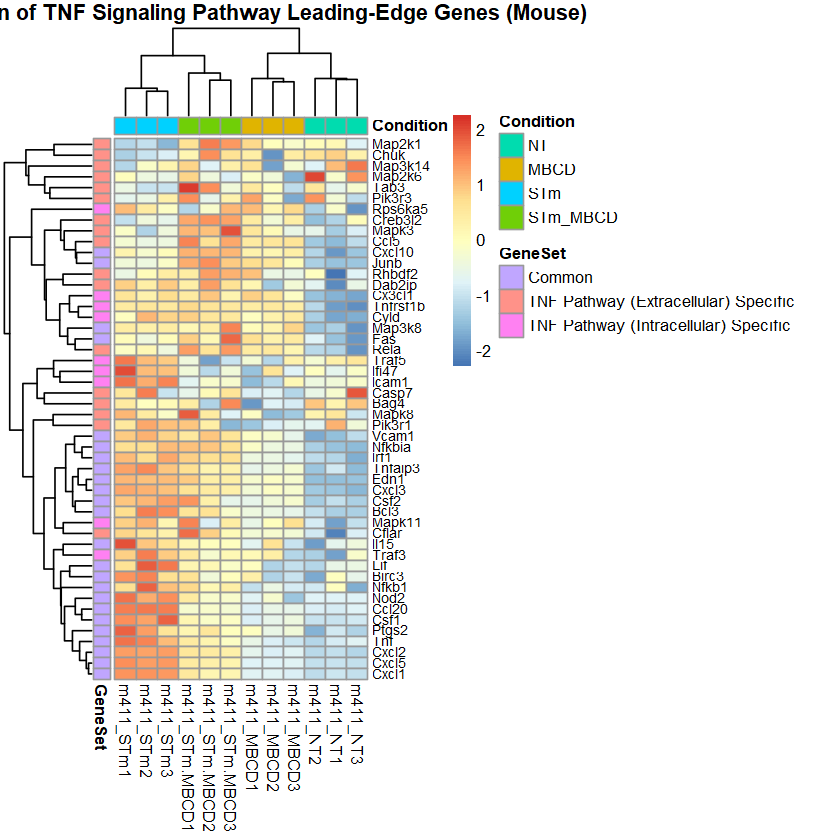

In [38]:
# --- TNF Signaling Pathway Leading-Edge Genes Heatmap (Mouse) ---

# Load necessary libraries
library(pheatmap)
library(RColorBrewer)
library(org.Mm.eg.db)  # 🧬 Use mouse gene annotation

# 1. Define the two sets of leading-edge genes (from your lists above)
genes_tnf_pathway_set1 <- c(
  'Cxcl5', 'Ccl20', 'Nod2', 'Cxcl1', 'Cxcl2', 'Vcam1', 'Tnf', 'Map3k8',
  'Csf2', 'Edn1', 'Csf1', 'Tnfaip3', 'Cxcl3', 'Nfkbia', 'Lif', 'Cx3cl1',
  'Il15', 'Ptgs2', 'Cxcl10', 'Irf1', 'Tnfrsf1b', 'Bcl3', 'Mapk11',
  'Rps6ka5', 'Traf3', 'Birc3', 'Nfkb1', 'Ifi47', 'Fas', 'Cyld',
  'Junb', 'Traf5', 'Icam1'
)

genes_tnf_pathway_set2 <- c(
  'Cxcl5', 'Cxcl1', 'Cxcl2', 'Nod2', 'Tnf', 'Ccl20', 'Vcam1', 'Nfkbia',
  'Csf2', 'Tnfaip3', 'Csf1', 'Irf1', 'Lif', 'Edn1', 'Cxcl3', 'Cxcl10',
  'Nfkb1', 'Mapk8', 'Bcl3', 'Map2k6', 'Tab3', 'Casp7', 'Junb', 'Bag4',
  'Rhbdf2', 'Birc3', 'Creb3l2', 'Map3k8', 'Ptgs2', 'Mapk3', 'Ccl5',
  'Cflar', 'Dab2ip', 'Map3k14', 'Map2k1', 'Pik3r3', 'Il15', 'Pik3r1',
  'Chuk', 'Fas', 'Rela'
)

# 2. Prepare the expression data for plotting
# Merge all unique genes from both sets
all_genes <- unique(c(genes_tnf_pathway_set1, genes_tnf_pathway_set2))

# Convert gene symbols to ENSEMBL IDs using org.Mm.eg.db
ensembl_ids_to_plot_list <- mapIds(
  org.Mm.eg.db,
  keys = all_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "list"
)

# Unlist and remove NA entries
ensembl_ids_to_plot <- unlist(na.omit(ensembl_ids_to_plot_list))

# Extract expression data (VST-normalized counts for mouse)
vst_counts <- assay(vsd_ms)  # 🧬 use the mouse VST matrix

# Ensure only ENSEMBL IDs that exist in vst_counts are used
ensembl_ids_in_vst <- intersect(ensembl_ids_to_plot, rownames(vst_counts))
heatmap_matrix <- vst_counts[ensembl_ids_in_vst, ]

# Convert ENSEMBL IDs back to gene symbols for readability
gene_symbols_for_rows <- mapIds(
  org.Mm.eg.db,
  keys = rownames(heatmap_matrix),
  column = "SYMBOL",
  keytype = "ENSEMBL",
  multiVals = "first"
)
rownames(heatmap_matrix) <- gene_symbols_for_rows

# 3. Create annotations
# Column annotation: sample conditions
annotation_col <- as.data.frame(colData(dds_ms)[, "condition_ms", drop = FALSE])
colnames(annotation_col) <- "Condition"

# Row annotation: which gene set each gene belongs to
common_genes <- intersect(genes_tnf_pathway_set1, genes_tnf_pathway_set2)
unique_set1 <- setdiff(genes_tnf_pathway_set1, common_genes)
unique_set2 <- setdiff(genes_tnf_pathway_set2, common_genes)

# Annotate only the genes in the heatmap
heatmap_genes <- rownames(heatmap_matrix)
gene_set_info <- rep("Unknown", length(heatmap_genes))
names(gene_set_info) <- heatmap_genes

gene_set_info[heatmap_genes %in% common_genes] <- "Common"
gene_set_info[heatmap_genes %in% unique_set1] <- "TNF Pathway (Intracellular) Specific"
gene_set_info[heatmap_genes %in% unique_set2] <- "TNF Pathway (Extracellular) Specific"

annotation_row <- data.frame(GeneSet = factor(gene_set_info))
rownames(annotation_row) <- heatmap_genes

# 4. Draw the heatmap
pheatmap(
  heatmap_matrix,
  main = "Expression of TNF Signaling Pathway Leading-Edge Genes (Mouse)",
  annotation_col = annotation_col,
  annotation_row = annotation_row,
  scale = "row",          # Z-score normalization across rows
  cluster_rows = TRUE,    # cluster genes
  cluster_cols = TRUE,    # cluster samples
  show_rownames = TRUE,
  fontsize_row = 8,
  fontsize_col = 10
)

IL-17 signaling pathway	

In [39]:
# --- 提取 IL-17 signaling pathway 的领头基因 (Intracellular, Mouse) ---

# 加载所需包
library(org.Mm.eg.db)  # 小鼠注释数据库
library(AnnotationDbi)

# 定义通路名称
pathway_name <- "IL-17 signaling pathway"

# 取出 GSEA 结果（小鼠版本）
gsea_result_df <- as.data.frame(gsea_res_NTSTM_ms)

# 找到该通路的 core_enrichment 基因ID（Entrez IDs）
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 将 core_enrichment 的字符串拆分成 Entrez ID 向量
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 将 Entrez ID 转换为基因符号 SYMBOL
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,            # 小鼠数据库
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 输出结果
cat("Leading-edge genes for '", pathway_name, "' in (Intracellular, mouse):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'IL-17 signaling pathway' in (Intracellular, mouse):


20311     20297     16819     14825     20310     21926     12981     21929 
  "Cxcl5"   "Ccl20"    "Lcn2"   "Cxcl1"   "Cxcl2"     "Tnf"    "Csf2" "Tnfaip3" 
   330122     18035     56489     19225     15945     19094     22031     18033 
  "Cxcl3"  "Nfkbia"   "Ikbke"   "Ptgs2"  "Cxcl10"  "Mapk11"   "Traf3"   "Nfkb1" 
    22033     23939 
  "Traf5"   "Mapk7"

In [40]:
# --- 提取 IL-17 signaling pathway 的领头基因 (Intracellular, Mouse) ---

# 加载所需包
library(org.Mm.eg.db)  # 小鼠注释数据库
library(AnnotationDbi)

# 定义通路名称
pathway_name <- "IL-17 signaling pathway"

# 取出 GSEA 结果（小鼠版本）
gsea_result_df <- as.data.frame(gsea_res_MBCD_ms)

# 找到该通路的 core_enrichment 基因ID（Entrez IDs）
core_enrichment_ids <- gsea_result_df[gsea_result_df$Description == pathway_name, "core_enrichment"]

# 将 core_enrichment 的字符串拆分成 Entrez ID 向量
leading_edge_entrez_ids <- strsplit(core_enrichment_ids, "/")[[1]]

# 将 Entrez ID 转换为基因符号 SYMBOL
leading_edge_symbols <- mapIds(
  org.Mm.eg.db,            # 小鼠数据库
  keys = leading_edge_entrez_ids,
  column = "SYMBOL",
  keytype = "ENTREZID",
  multiVals = "first"
)

# 输出结果
cat("Leading-edge genes for '", pathway_name, "' in (MBCD vs MBCDSTm, mouse):\n", sep = "")
leading_edge_symbols


'select()' returned 1:1 mapping between keys and columns



Leading-edge genes for 'IL-17 signaling pathway' in (MBCD vs MBCDSTm, mouse):


20311      14825      20310      21926      20297      18035      12981 
   "Cxcl5"    "Cxcl1"    "Cxcl2"      "Tnf"    "Ccl20"   "Nfkbia"     "Csf2" 
     50905      21929     330122      15945      18033      26419      66724 
  "Il17rb"  "Tnfaip3"    "Cxcl3"   "Cxcl10"    "Nfkb1"    "Mapk8"     "Tab3" 
     56489      19225      26417     103213      16819 
   "Ikbke"    "Ptgs2"    "Mapk3" "Traf3ip2"     "Lcn2"

'select()' returned 1:1 mapping between keys and columns



'select()' returned 1:1 mapping between keys and columns



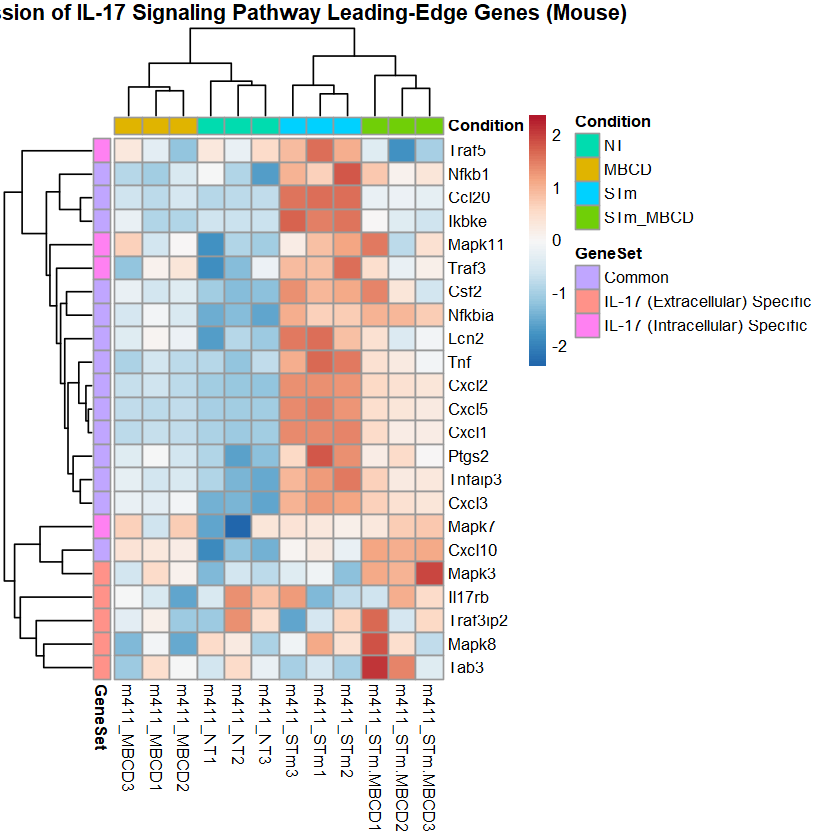

In [41]:
# --- 绘制 IL-17 signaling pathway 领头基因热图 (Mouse) ---

# 加载必要包
library(pheatmap)
library(RColorBrewer)
library(org.Mm.eg.db)
library(AnnotationDbi)

# 1. 定义两组新的领头基因
genes_il17_set1 <- c(
  'Cxcl5', 'Ccl20', 'Lcn2', 'Cxcl1', 'Cxcl2', 'Tnf', 'Csf2', 'Tnfaip3',
  'Cxcl3', 'Nfkbia', 'Ikbke', 'Ptgs2', 'Cxcl10', 'Mapk11', 'Traf3',
  'Nfkb1', 'Traf5', 'Mapk7'
)

genes_il17_set2 <- c(
  'Cxcl5', 'Cxcl1', 'Cxcl2', 'Tnf', 'Ccl20', 'Nfkbia', 'Csf2', 'Il17rb',
  'Tnfaip3', 'Cxcl3', 'Cxcl10', 'Nfkb1', 'Mapk8', 'Tab3', 'Ikbke',
  'Ptgs2', 'Mapk3', 'Traf3ip2', 'Lcn2'
)

# 2. 准备用于绘图的数据
# 合并并获取所有唯一基因的列表
all_genes <- unique(c(genes_il17_set1, genes_il17_set2))

# 将基因符号转换为 ENSEMBL ID（小鼠）
ensembl_ids_to_plot_list <- mapIds(
  org.Mm.eg.db,
  keys = all_genes,
  column = "ENSEMBL",
  keytype = "SYMBOL",
  multiVals = "list"
)
# 展开列表并移除 NA
ensembl_ids_to_plot <- unlist(na.omit(ensembl_ids_to_plot_list))

# 取出 VST 转换后的表达矩阵（小鼠）
vst_counts <- assay(vsd_ms)

# 确保基因在数据中存在
ensembl_ids_in_vst <- intersect(ensembl_ids_to_plot, rownames(vst_counts))
heatmap_matrix <- vst_counts[ensembl_ids_in_vst, ]

# 将 ENSEMBL ID 转回 SYMBOL，方便显示
gene_symbols_for_rows <- mapIds(
  org.Mm.eg.db,
  keys = rownames(heatmap_matrix),
  column = "SYMBOL",
  keytype = "ENSEMBL",
  multiVals = "first"
)
rownames(heatmap_matrix) <- gene_symbols_for_rows

# 3. 创建注释信息
# 为列（样本）创建注释
annotation_col <- as.data.frame(colData(dds_ms)[, "condition_ms", drop = FALSE])
colnames(annotation_col) <- "Condition"

# 为行（基因）创建注释
common_genes <- intersect(genes_il17_set1, genes_il17_set2)
unique_set1 <- setdiff(genes_il17_set1, common_genes)
unique_set2 <- setdiff(genes_il17_set2, common_genes)

# 只为热图中存在的基因添加注释
heatmap_genes <- rownames(heatmap_matrix)
gene_set_info <- rep("Unknown", length(heatmap_genes))
names(gene_set_info) <- heatmap_genes

gene_set_info[heatmap_genes %in% common_genes] <- "Common"
gene_set_info[heatmap_genes %in% unique_set1] <- "IL-17 (Intracellular) Specific"
gene_set_info[heatmap_genes %in% unique_set2] <- "IL-17 (Extracellular) Specific"

annotation_row <- data.frame(GeneSet = factor(gene_set_info))
rownames(annotation_row) <- heatmap_genes

# 4. 绘制热图
pheatmap(
  heatmap_matrix,
  main = "Expression of IL-17 Signaling Pathway Leading-Edge Genes (Mouse)",
  annotation_col = annotation_col,
  annotation_row = annotation_row,
  scale = "row",           # 对行进行 Z-score 标准化
  cluster_rows = TRUE,     # 聚类行
  cluster_cols = TRUE,     # 聚类列
  show_rownames = TRUE,
  fontsize_row = 10,
  fontsize_col = 10,
  color = colorRampPalette(rev(brewer.pal(n = 9, name = "RdBu")))(100)
)